# Notebook 1: Data Loading, Feature Engineering & EDA

**Dataset:** PhysioNet/CinC Challenge 2019 — Early Prediction of Sepsis  
**Task:** Binary classification — predict whether a patient develops sepsis  
**Input:** `sepsis_dataset.csv`  
**Output:** `patient_data.csv`

---

## What this notebook does
1. Mount Google Drive and load the raw dataset
2. Inspect the raw data structure
3. Convert the hourly time-series into one row per patient using feature engineering
4. Save the aggregated dataset as `patient_data.csv`
5. EDA — class distribution, missing values, feature distributions, correlations, demographics

## 1. Mount Google Drive

In [1]:
# Colab-optional: mount Google Drive only when running on Colab; no-op locally.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except (ImportError, ModuleNotFoundError):
    pass  # running locally -- no Drive to mount


## 2. Configuration

Update `data_dir` to the folder on your Google Drive where the dataset is stored. All output files will be saved to the same folder.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import google.colab  # noqa: F401
    data_dir = Path('/content/drive/MyDrive/Colab Notebooks/Sepsis ML Project')
except ImportError:
    data_dir = Path.cwd()   # local run: dataset + generated files live in the repo root
data_file = 'Sepsis_Dataset.csv'

patient_id_col = 'Patient_ID'

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

## 3. Load the Raw Dataset

The raw dataset has one row per hour per patient. A patient who was in the ICU for 48 hours will have 48 rows. Before we can do machine learning, we need to collapse this into one row per patient — that is the feature engineering step in Section 4.

In [3]:
raw_df = pd.read_csv(data_dir / data_file)

print(f'Rows (hourly records) : {raw_df.shape[0]:,}')
print(f'Columns               : {raw_df.shape[1]}')
print(f'Unique patients       : {raw_df[patient_id_col].nunique():,}')
raw_df.head(3)

Rows (hourly records) : 1,552,210
Columns               : 44
Unique patients       : 40,336


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072


## 4. Feature Engineering -- Aggregation

The raw data is a time-series -- each row is one hour of measurements for one patient. Machine learning models expect one row per patient, so we summarise each patient's entire ICU stay into a single row.

For vital signs and lab values we compute four aggregations per patient:

| Aggregation | What it captures |
|---|---|
| `_min` | Lowest recorded value across all ICU hours |
| `_max` | Peak value -- highest severity reached |
| `_mean` | Average over the entire ICU stay |
| `_std` | Standard deviation -- how much the measurement fluctuated. High std means the value was unstable, which is a clinical warning sign |
| `_range` | `max - min` -- the total spread. Captures instability with less redundancy than keeping both `_min` and `_max` separately |

**Additional features:**

| Column | Aggregation | Reason |
|---|---|---|
| `Age`, `Gender` | first | Same value every hour |
| `ICULOS` | max | Total ICU length of stay in hours -- a patient-level summary that is meaningful (longer stays correlate with more complex cases) |
| `SepsisLabel` | max | 1 if the patient ever developed sepsis, else 0 |

**Columns dropped:**

| Column | Reason |
|---|---|
| `Unit1`, `Unit2` | Administrative ICU unit IDs -- not a clinical signal |
| `HospAdmTime` | Time between hospital and ICU admission -- metadata |

We use separate `groupby().agg()` operations and then `join()` them together.


In [4]:
# CAVEAT: these aggregations span the patient's ENTIRE ICU stay, including
# hours AFTER sepsis onset. The target below is SepsisLabel.max() (ever septic).
# So this is a RETROSPECTIVE whole-stay classifier, not a real-time early
# warning system -- e.g. Lactate_max may come from after onset. A true early
# predictor would aggregate only measurements up to a fixed cutoff time and
# re-run the pipeline. See the Limitations section in README.md.
demographic_cols   = ['Age', 'Gender']
vital_and_lab_cols = [
    'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2',
    'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
    'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
    'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
    'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
    'Fibrinogen', 'Platelets'
]

# Demographics: same every hour -- take first value per patient
demographics = raw_df.groupby(patient_id_col)[demographic_cols].first()

# Vitals and labs: compute min, max, mean, std across all hours per patient
vitals_labs = raw_df.groupby(patient_id_col)[vital_and_lab_cols].agg(
    ['min', 'max', 'mean', 'std']
)

# Flatten multi-level column names: ('HR', 'min') -> 'HR_min'
vitals_labs.columns = ['_'.join(col) for col in vitals_labs.columns]

# Range features: max - min captures spread with less redundancy
# than keeping both _min and _max as separate features
for col in vital_and_lab_cols:
    vitals_labs[f'{col}_range'] = vitals_labs[f'{col}_max'] - vitals_labs[f'{col}_min']

# ICU length of stay: max ICULOS = total hours in ICU for this patient
iculos = raw_df.groupby(patient_id_col)['ICULOS'].max().rename('ICULOS_max')

# Target: 1 if the patient ever had SepsisLabel = 1, else 0
target = raw_df.groupby(patient_id_col)['SepsisLabel'].max().rename('Sepsis')

# Combine all into one row per patient
patient_df = demographics.join(vitals_labs).join(iculos).join(target)

n_features = patient_df.shape[1] - 1
print(f'Patients : {patient_df.shape[0]:,}')
print(f'Features : {n_features}  +  1 target column (Sepsis)')
print(f'  (34 vitals/labs x 5 aggs = 170, + ICULOS_max, Age, Gender = {n_features})')
patient_df.head(3)


Patients : 40,336
Features : 173  +  1 target column (Sepsis)
  (34 vitals/labs x 5 aggs = 170, + ICULOS_max, Age, Gender = 173)


,Age,Gender,HR_min,HR_max,HR_mean,HR_std,O2Sat_min,O2Sat_max,O2Sat_mean,O2Sat_std,...,Bilirubin_total_range,TroponinI_range,Hct_range,Hgb_range,PTT_range,WBC_range,Fibrinogen_range,Platelets_range,ICULOS_max,Sepsis
Patient_ID,,,,,,,,,,,,,,,,,,,,,
1,83.14,0,76.0,117.0,101.571429,9.594378,85.0,100.0,91.477273,3.460667,...,0.0,NaN,1.0,0.3,NaN,9.0,NaN,21.0,54,0
2,75.91,0,54.0,94.0,60.954545,8.144395,94.0,100.0,97.000000,2.138090,...,NaN,NaN,0.0,0.0,NaN,0.0,NaN,0.0,23,0
3,45.82,0,68.0,93.0,79.611111,6.714036,91.0,99.0,95.431818,1.655122,...,NaN,NaN,5.9,2.2,1.0,1.7,NaN,23.0,48,0


## 5. Save Aggregated Dataset

In [5]:
patient_df.to_csv(data_dir / 'patient_data.csv')
print(f'Saved: {data_dir}/patient_data.csv')

Saved: C:\Users\sbokk\OneDrive\Desktop\GITHUB REPOS\Sepsis-ML-Model/patient_data.csv


## 6. EDA — Class Distribution

Sepsis is a rare event. Only a small fraction of ICU patients develop it. This **class imbalance** is one of the most important properties of this dataset.

If we ignore it, a model could achieve high accuracy by simply predicting Non-Sepsis for every single patient — while catching zero actual sepsis cases. That would be clinically useless.

This is why we use F1 score instead of accuracy as our evaluation metric, and why we use `class_weight='balanced'` in the models.

Non-Sepsis (0) : 37,404  (92.7%)
Sepsis     (1) : 2,932  (7.3%)


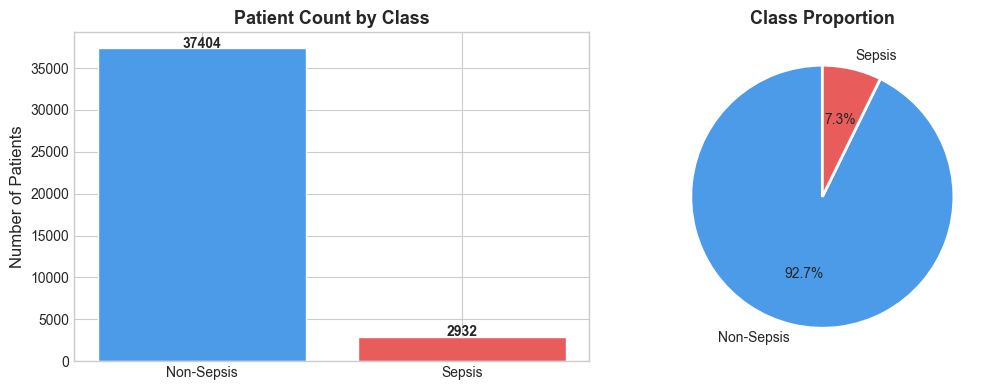

In [6]:
class_counts     = patient_df['Sepsis'].value_counts()
non_sepsis_count = class_counts[0]
sepsis_count     = class_counts[1]
non_sepsis_pct   = non_sepsis_count / len(patient_df) * 100
sepsis_pct       = sepsis_count     / len(patient_df) * 100

print(f'Non-Sepsis (0) : {non_sepsis_count:,}  ({non_sepsis_pct:.1f}%)')
print(f'Sepsis     (1) : {sepsis_count:,}  ({sepsis_pct:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['Non-Sepsis', 'Sepsis'], [non_sepsis_count, sepsis_count],
            color=['#4C9BE8', '#E85C5C'], edgecolor='white')
axes[0].set_title('Patient Count by Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Patients', fontsize=12)
for i, v in enumerate([non_sepsis_count, sepsis_count]):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie([non_sepsis_count, sepsis_count],
            labels=['Non-Sepsis', 'Sepsis'],
            colors=['#4C9BE8', '#E85C5C'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. EDA — Missing Value Analysis

Lab values in the ICU are not drawn every hour — they are ordered only when clinically indicated. This means some lab columns will have high missing rates.

Columns where more than 90% of values are missing will be dropped in Notebook 2. Imputing 90% of a column with a guessed value would introduce more noise than signal.

Features with >90% missing : 12
Features with >50% missing : 69
Features with   0% missing : 3


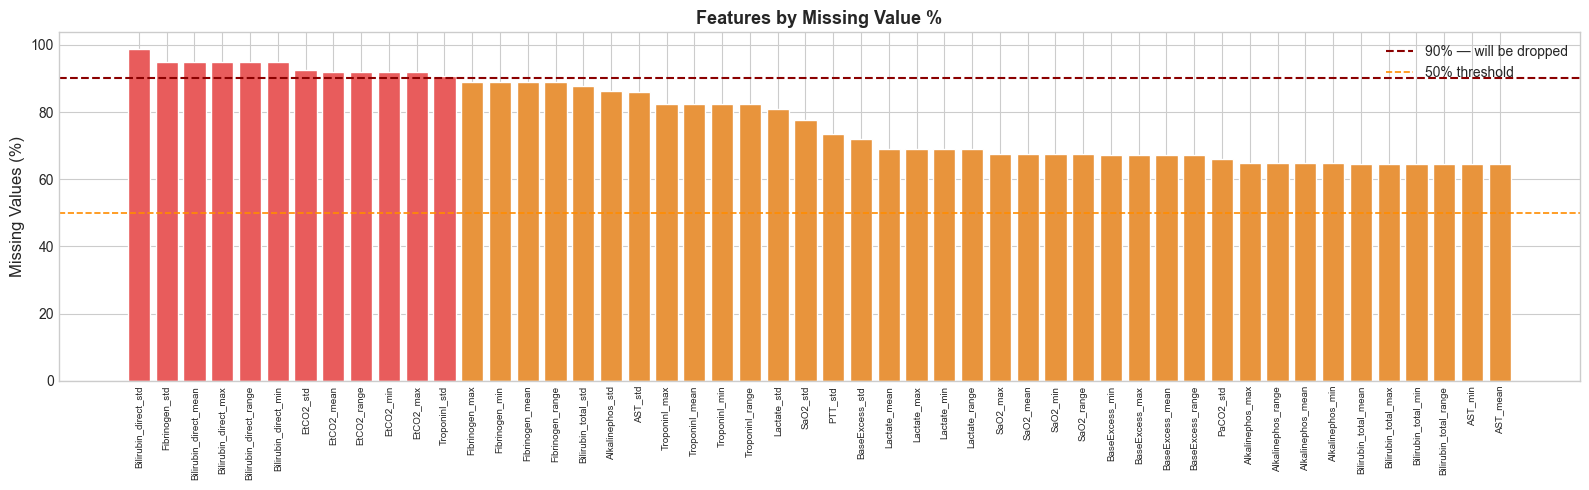

In [7]:
features_only = patient_df.drop(columns=['Sepsis'])
null_pct      = (features_only.isnull().sum() / len(features_only) * 100).sort_values(ascending=False)

print(f'Features with >90% missing : {(null_pct > 90).sum()}')
print(f'Features with >50% missing : {(null_pct > 50).sum()}')
print(f'Features with   0% missing : {(null_pct == 0).sum()}')

to_plot = null_pct[null_pct > 0].head(50)
colours = ['#E85C5C' if v > 90 else '#E8943C' if v > 50 else '#4C9BE8' for v in to_plot]

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(to_plot)), to_plot.values, color=colours, edgecolor='white')
ax.axhline(90, color='darkred',    linestyle='--', linewidth=1.5, label='90% — will be dropped')
ax.axhline(50, color='darkorange', linestyle='--', linewidth=1.2, label='50% threshold')
ax.set_xticks(range(len(to_plot)))
ax.set_xticklabels(to_plot.index, rotation=90, fontsize=7)
ax.set_ylabel('Missing Values (%)', fontsize=12)
ax.set_title('Features by Missing Value %', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 8. EDA — Feature Distributions: Sepsis vs Non-Sepsis

For each feature (using the mean value across the patient's stay), we compare the distribution between sepsis and non-sepsis patients. Features where the two distributions look clearly different are likely to be useful for prediction — they indicate that sepsis patients have systematically different physiology.

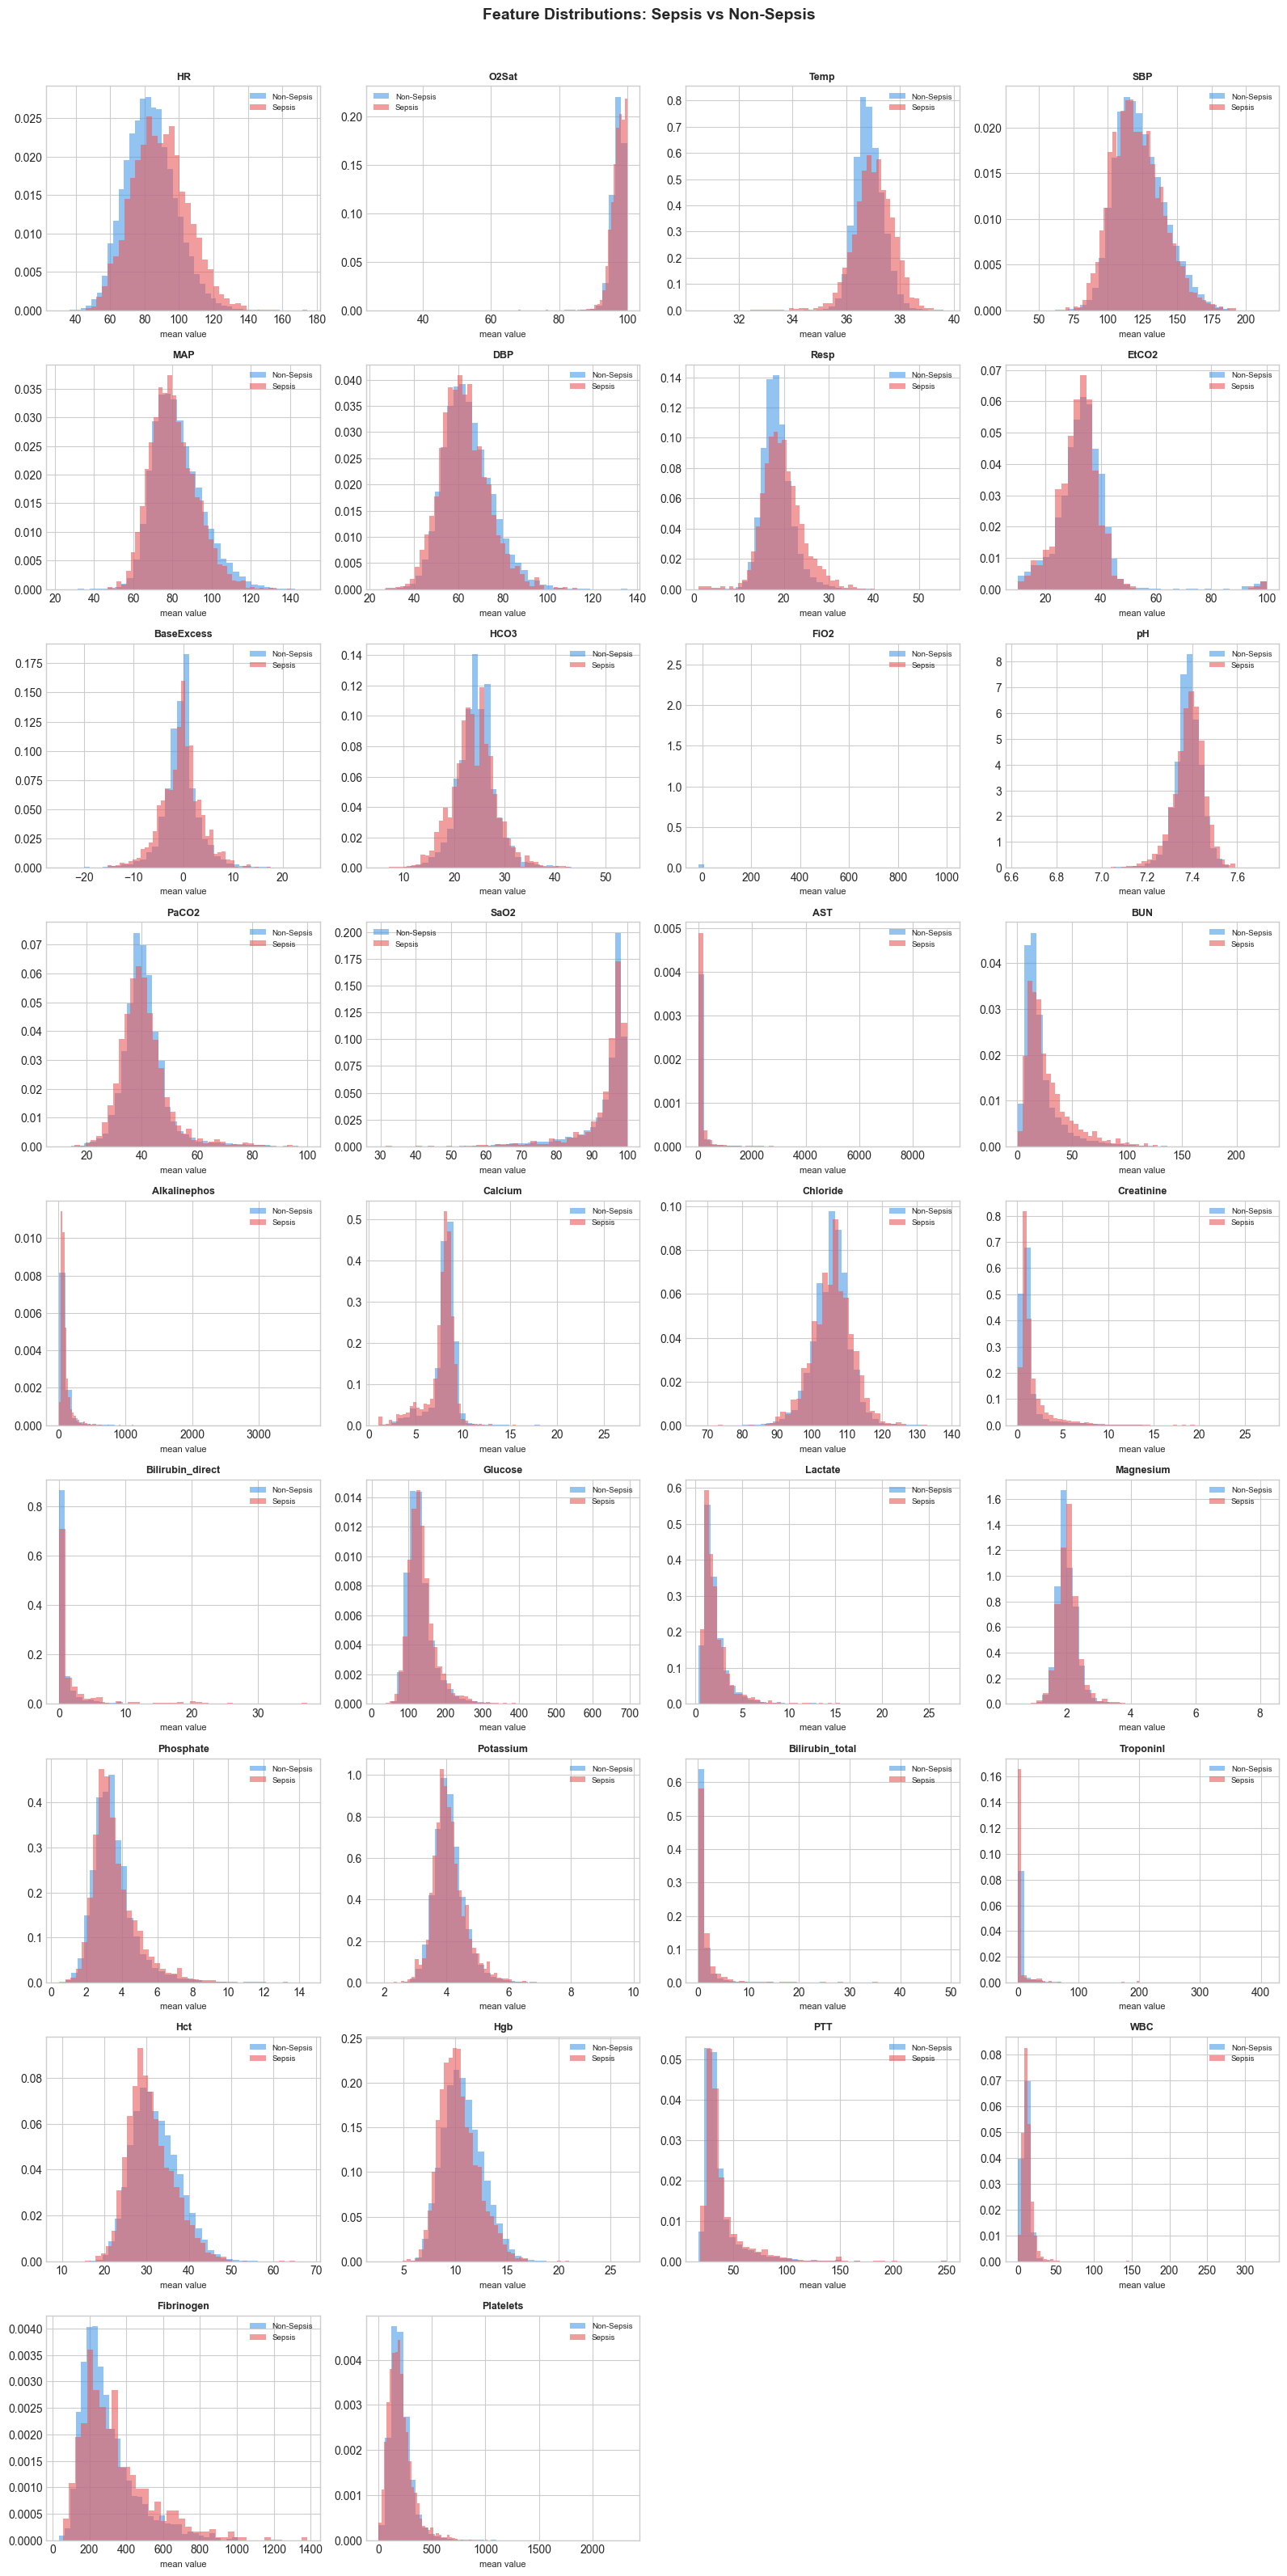

In [8]:
sepsis_0  = patient_df[patient_df['Sepsis'] == 0]
sepsis_1  = patient_df[patient_df['Sepsis'] == 1]
mean_cols = [col for col in patient_df.columns if col.endswith('_mean')]

n_cols = 4
n_rows = (len(mean_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(mean_cols):
    axes[i].hist(sepsis_0[col].dropna(), bins=40, alpha=0.6,
                 color='#4C9BE8', label='Non-Sepsis', density=True)
    axes[i].hist(sepsis_1[col].dropna(), bins=40, alpha=0.6,
                 color='#E85C5C', label='Sepsis',     density=True)
    axes[i].set_title(col.replace('_mean', ''), fontsize=9, fontweight='bold')
    axes[i].set_xlabel('mean value', fontsize=8)
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Sepsis vs Non-Sepsis',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. EDA — Box Plots by Sepsis Status

Box plots show the median, interquartile range, and outliers for each feature by sepsis status. A large difference between the two boxes — especially a non-overlapping interquartile range — indicates a feature that clearly distinguishes sepsis from non-sepsis patients.

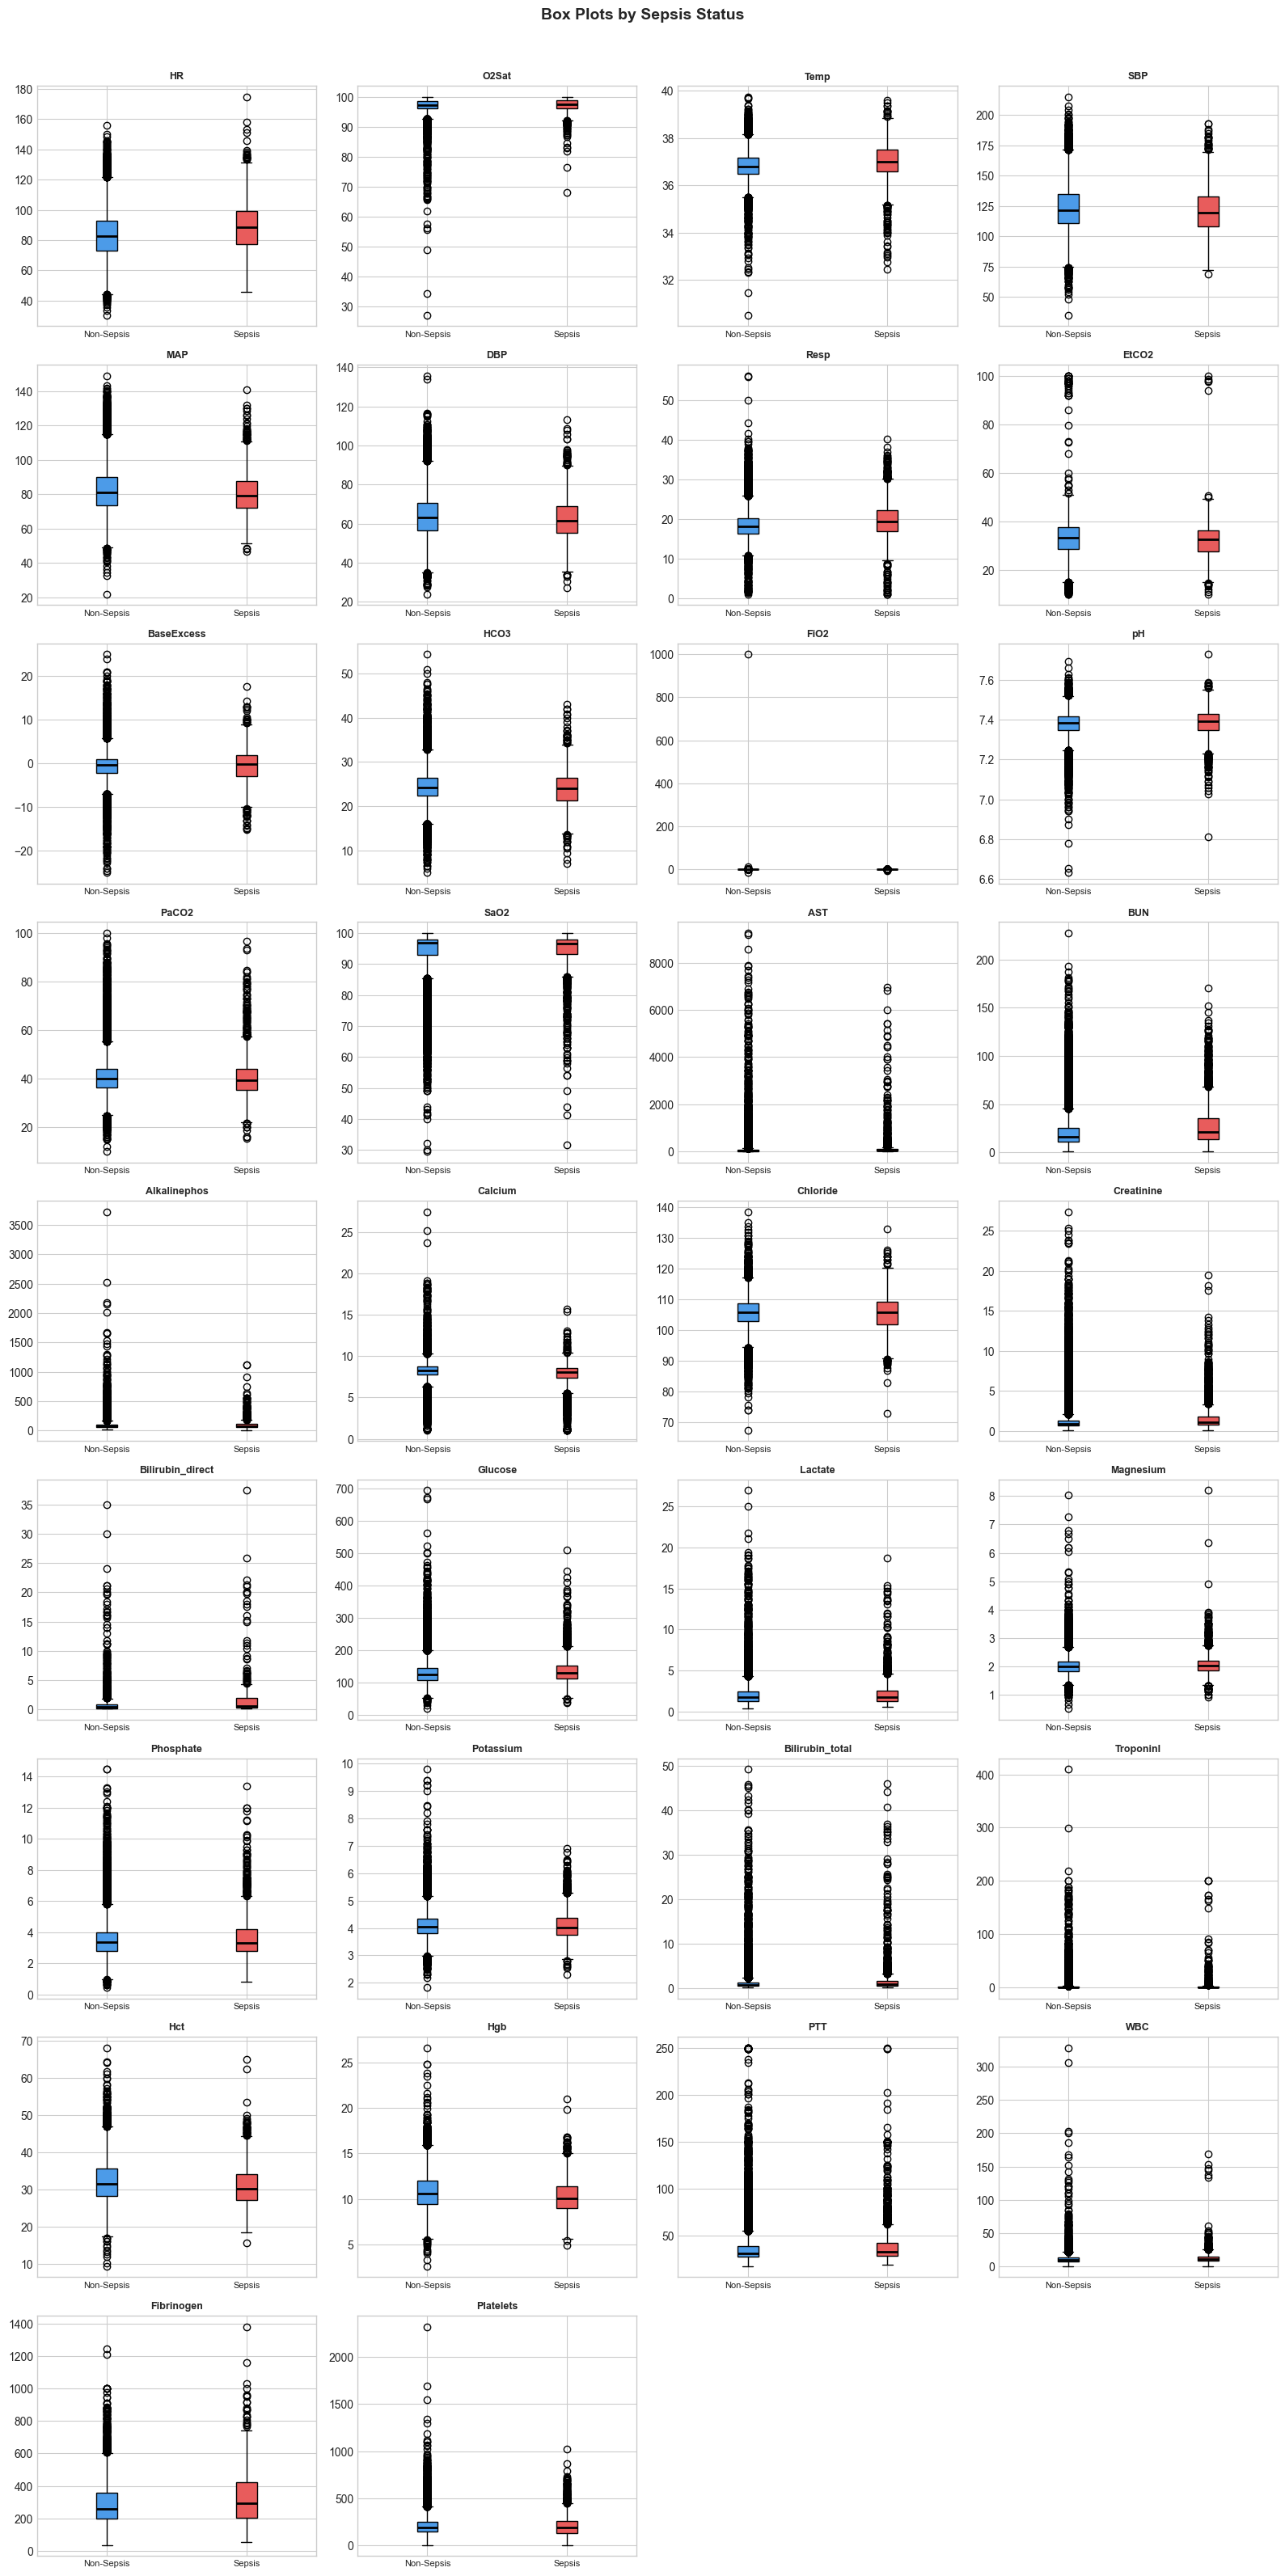

In [9]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(mean_cols):
    data = [sepsis_0[col].dropna().values, sepsis_1[col].dropna().values]
    bp   = axes[i].boxplot(data, patch_artist=True,
                           medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('#4C9BE8')
    bp['boxes'][1].set_facecolor('#E85C5C')
    axes[i].set_xticklabels(['Non-Sepsis', 'Sepsis'], fontsize=8)
    axes[i].set_title(col.replace('_mean', ''), fontsize=9, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots by Sepsis Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 10. EDA — Correlation Heatmap

The heatmap shows the Pearson correlation between every pair of mean-aggregated features. Dark red = strong positive correlation, dark blue = strong negative correlation, white/light = little relationship.

Highly correlated pairs carry overlapping information. The RFE step in Notebook 2 handles this by selecting only the features that are most predictive, naturally discarding redundant ones.

**Why it looks like a staircase:**
A correlation matrix is perfectly symmetrical (the correlation between Heart Rate and Temp is the same as Temp and Heart Rate). To avoid showing redundant information and the solid diagonal line of 1s (features correlated with themselves), the top right half is intentionally hidden (masked), giving it that stepped shape. Only the lower triangle is shown.

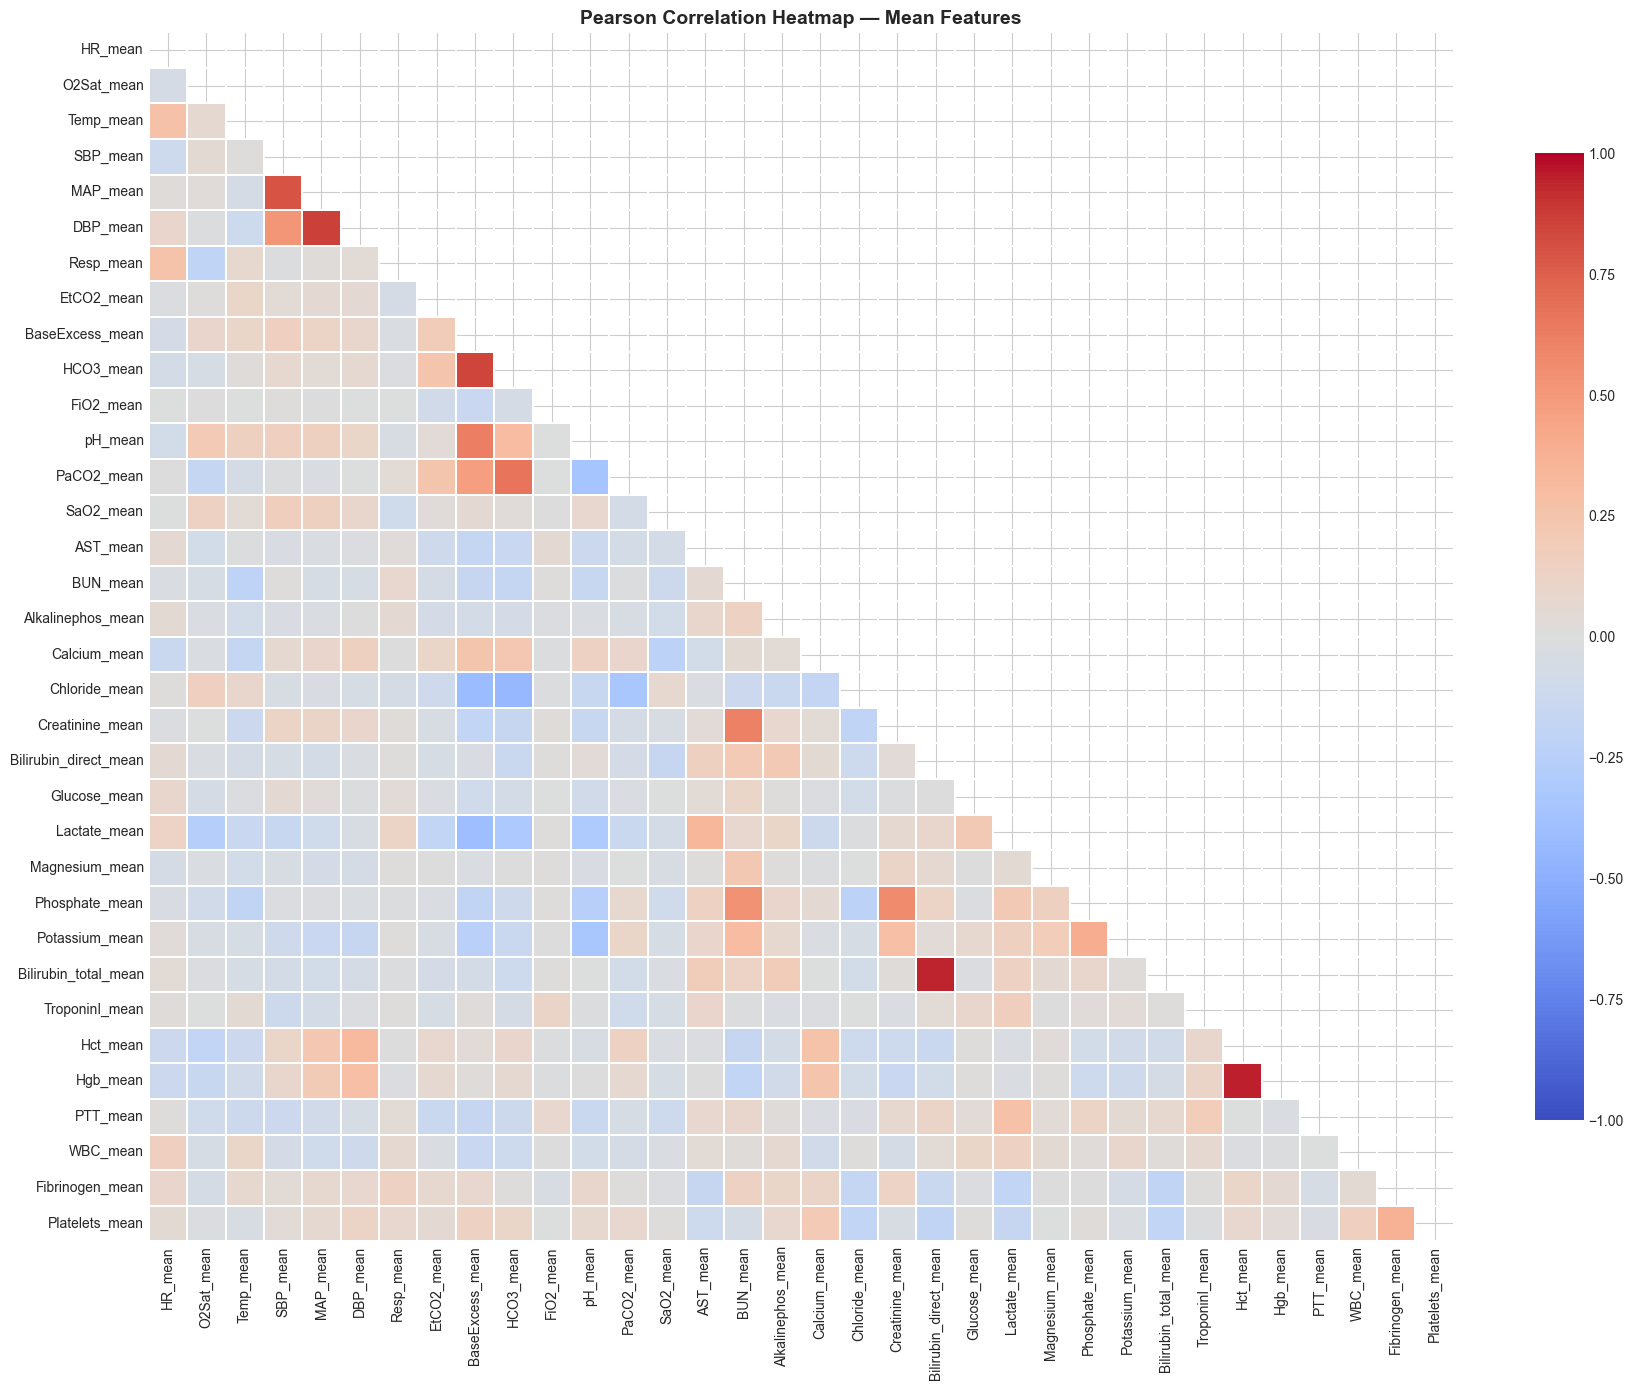

In [10]:
mean_cols   = [c for c in patient_df.columns if c.endswith('_mean')]
corr_matrix = patient_df[mean_cols].corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, annot=False, linewidths=0.3,
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Pearson Correlation Heatmap — Mean Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. EDA — Age & Gender

Age and gender are patient-level demographics that remain constant across all hourly records. We check whether they are associated with sepsis risk in this dataset.

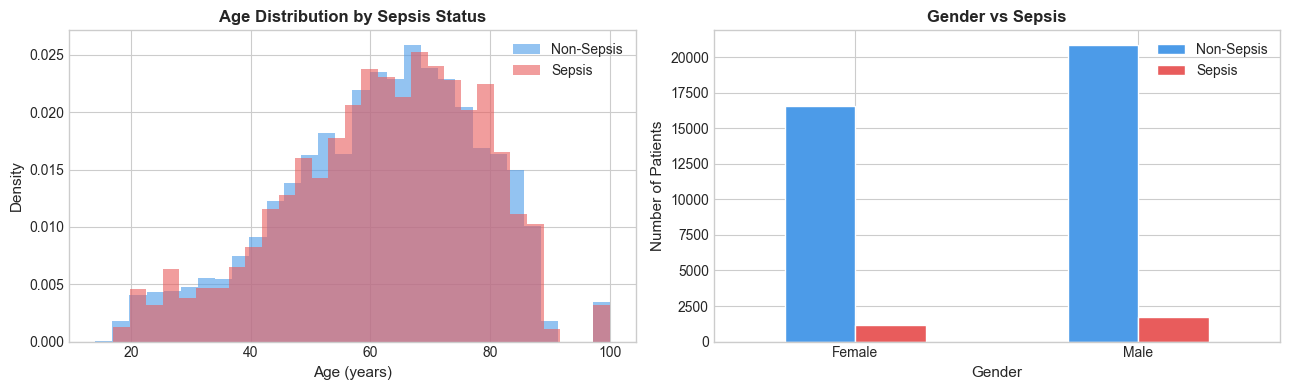

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

if 'Age' in patient_df.columns:
    axes[0].hist(sepsis_0['Age'].dropna(), bins=30, alpha=0.6,
                 color='#4C9BE8', label='Non-Sepsis', density=True)
    axes[0].hist(sepsis_1['Age'].dropna(), bins=30, alpha=0.6,
                 color='#E85C5C', label='Sepsis',     density=True)
    axes[0].set_title('Age Distribution by Sepsis Status', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Age (years)', fontsize=11)
    axes[0].set_ylabel('Density', fontsize=11)
    axes[0].legend(fontsize=10)

if 'Gender' in patient_df.columns:
    gender_sepsis = patient_df.groupby(['Gender', 'Sepsis']).size().unstack(fill_value=0)
    gender_sepsis.index = ['Female' if i == 0 else 'Male' for i in gender_sepsis.index]
    gender_sepsis.columns = ['Non-Sepsis', 'Sepsis']
    gender_sepsis.plot(kind='bar', ax=axes[1],
                       color=['#4C9BE8', '#E85C5C'], edgecolor='white')
    axes[1].set_title('Gender vs Sepsis', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Gender', fontsize=11)
    axes[1].set_ylabel('Number of Patients', fontsize=11)
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

## 12. Dataset Summary

In [12]:
print('DATASET SUMMARY')
print(f'Total patients        : {len(patient_df):,}')
print(f'Feature columns       : {patient_df.shape[1] - 1}')
print(f'Sepsis (1)            : {patient_df["Sepsis"].sum():,}  ({patient_df["Sepsis"].mean()*100:.1f}%)')
print(f'Non-sepsis (0)        : {(patient_df["Sepsis"]==0).sum():,}  ({(1-patient_df["Sepsis"].mean())*100:.1f}%)')
print(f'Overall null rate     : {patient_df.drop(columns="Sepsis").isnull().mean().mean()*100:.1f}%')
print()
print('Next: run 02_preprocessing.ipynb')

DATASET SUMMARY
Total patients        : 40,336
Feature columns       : 173
Sepsis (1)            : 2,932  (7.3%)
Non-sepsis (0)        : 37,404  (92.7%)
Overall null rate     : 36.9%

Next: run 02_preprocessing.ipynb
